<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Line Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.



## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [2]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


--2026-03-09 20:49:34--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
connected. to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... 
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  35.4MB/s    in 4.3s    

2026-03-09 20:49:39 (35.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



#### Step 2: Import necessary libraries and load the dataset


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#### Load the data


In [4]:
df = pd.read_csv("survey-data.csv")


#### Display the first few rows to understand the structure of the data


In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


null values before cleaning 42002


null values after cleaning 0


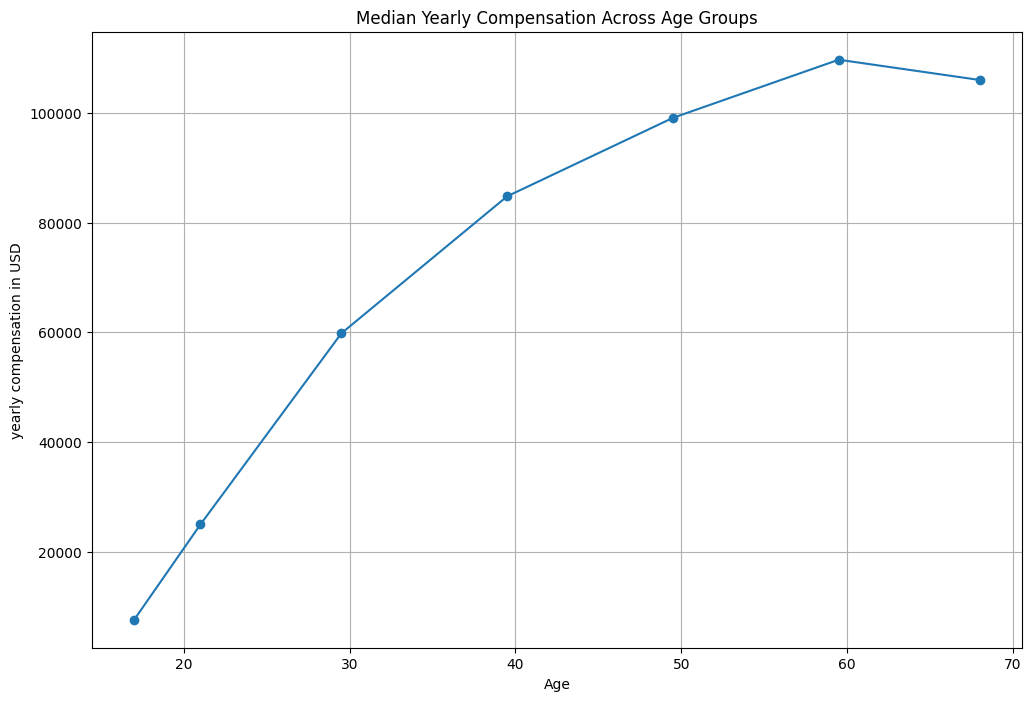

In [6]:
## Write your code here

comp_age=df[['Age','ConvertedCompYearly']].copy()

print('null values before cleaning',comp_age['ConvertedCompYearly'].isnull().sum())
comp_age=comp_age.dropna(subset=['ConvertedCompYearly'])
print('\n\nnull values after cleaning',comp_age['ConvertedCompYearly'].isnull().sum())

comp_age=comp_age[comp_age['Age']!='Prefer not to say']                                   # remove non-informative age responses

comp_age['Age']=comp_age['Age'].replace({                                                 # Age ranges were converted to approximate numeric midpoints to allow quantitative analysis and linear visualization
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

comp_age['Age']=pd.to_numeric(comp_age['Age'],errors='coerce')
comp_age = comp_age.dropna(subset=['Age'])

comp_median=comp_age.groupby('Age')['ConvertedCompYearly'].median()

comp_median.plot(
    kind='line'
    ,marker='o'
    ,figsize=(12,8)
    ,grid=True
    ,ylabel='yearly compensation in USD'
    ,title='Median Yearly Compensation Across Age Groups'
)
plt.show()

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


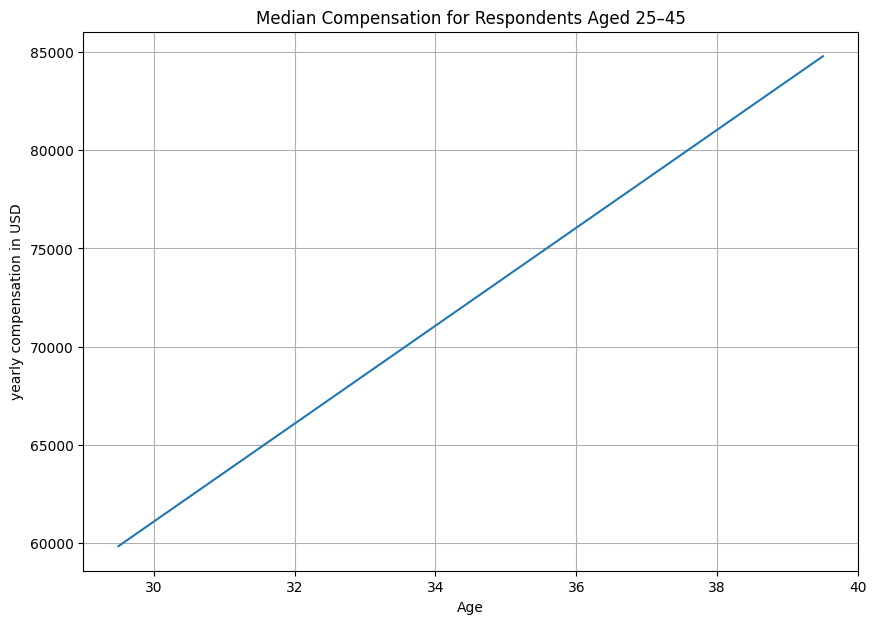

In [7]:
## Write your code here

comp_median25_45=comp_median.loc[25:46]

comp_median25_45.plot(
    kind='line'
    ,grid=True
    ,figsize=(10,7)
    ,ylabel='yearly compensation in USD'
    ,title='Median Compensation for Respondents Aged 25–45'
)
plt.show()

### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


null values before cleaning

 WorkExp           35779
JobSatPoints_6    35987
dtype: int64



null values after cleaning

 WorkExp           0
JobSatPoints_6    0
dtype: int64


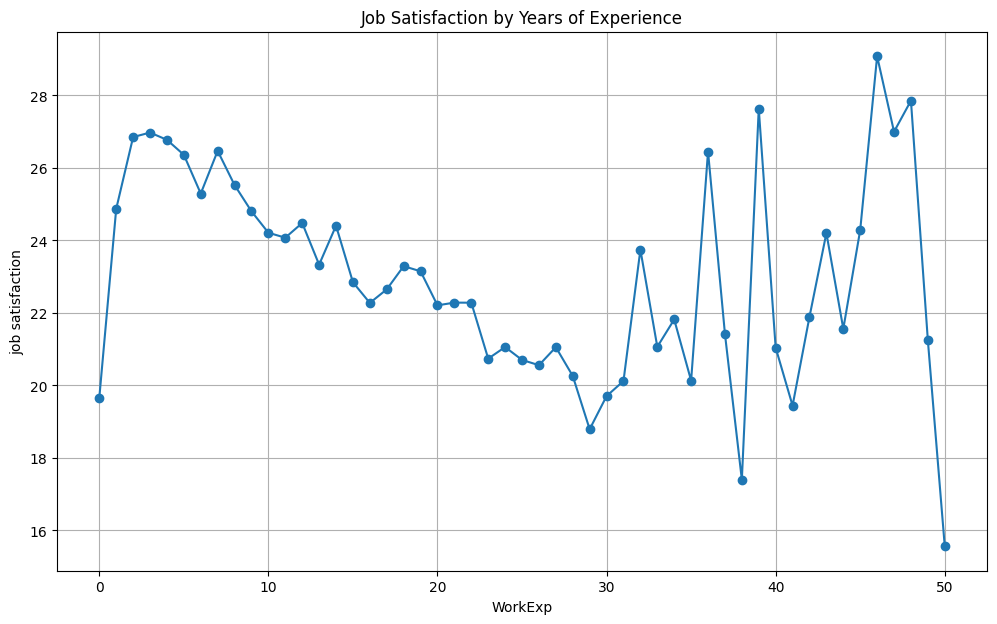

In [8]:
## Write your code here

exp_sat=df[['WorkExp','JobSatPoints_6']].copy()

print('null values before cleaning\n\n',exp_sat[['WorkExp','JobSatPoints_6']].isnull().sum())
exp_sat=exp_sat.dropna(subset=['WorkExp','JobSatPoints_6'])
print('\n\n\nnull values after cleaning\n\n',exp_sat[['WorkExp','JobSatPoints_6']].isnull().sum())

avg_satisfaction=exp_sat.groupby('WorkExp')['JobSatPoints_6'].mean()

avg_satisfaction.plot(
    kind='line'
    ,marker='o'
    ,grid=True
    ,figsize=(12,7)
    ,ylabel='job satisfaction'
    ,title='Job Satisfaction by Years of Experience'
)
plt.show()

In [9]:
exp_sat.groupby('WorkExp').size()

WorkExp
0.0      186
1.0     1430
2.0     1861
3.0     2111
4.0     1751
5.0     2028
6.0     1572
7.0     1555
8.0     1535
9.0      971
10.0    2006
11.0     806
12.0    1234
13.0     729
14.0     644
15.0    1222
16.0     595
17.0     589
18.0     578
19.0     327
20.0    1064
21.0     248
22.0     317
23.0     266
24.0     380
25.0     779
26.0     250
27.0     213
28.0     209
29.0     116
30.0     455
31.0      81
32.0      99
33.0      90
34.0      84
35.0     215
36.0      88
37.0      59
38.0      55
39.0      36
40.0     139
41.0      36
42.0      47
43.0      34
44.0      32
45.0      45
46.0      12
47.0       5
48.0       7
49.0       4
50.0      53
dtype: int64

### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


null values before cleaning

 WorkExp                35779
ConvertedCompYearly    42002
dtype: int64



null values after cleaning

 WorkExp                0
ConvertedCompYearly    0
dtype: int64


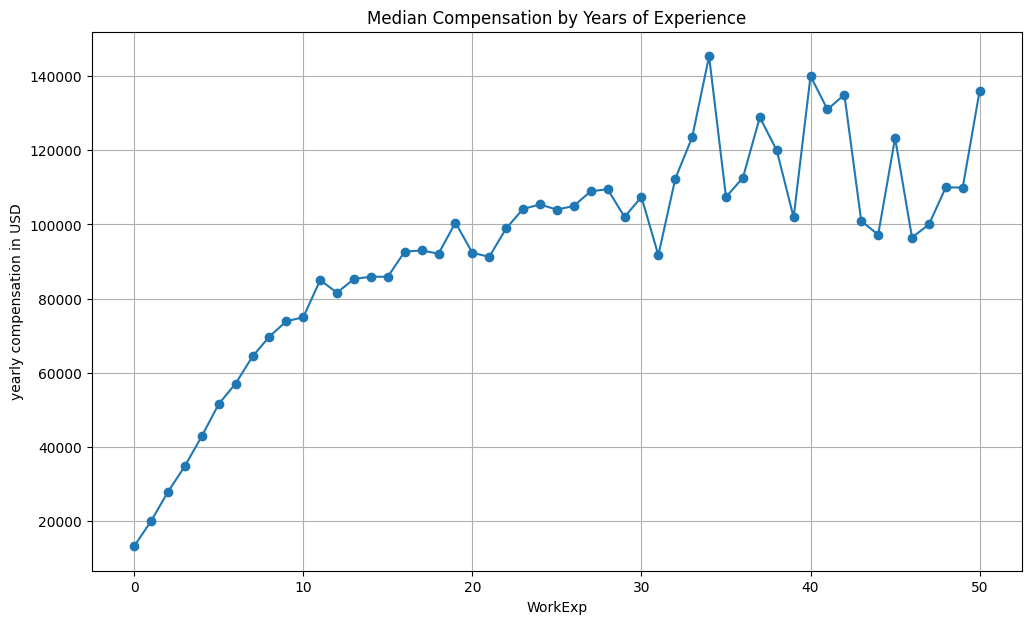

In [10]:
## Write your code here

comp_exp=df[['WorkExp','ConvertedCompYearly']].copy()

print('null values before cleaning\n\n',comp_exp[['WorkExp','ConvertedCompYearly']].isnull().sum())
comp_exp=comp_exp.dropna(subset=['ConvertedCompYearly','WorkExp'])
print('\n\n\nnull values after cleaning\n\n',comp_exp[['WorkExp','ConvertedCompYearly']].isnull().sum())

median_compensation=comp_exp.groupby('WorkExp')['ConvertedCompYearly'].median()

median_compensation.plot(
    kind='line'
    ,marker='o'
    ,grid=True
    ,figsize=(12,7)
    ,ylabel='yearly compensation in USD'
    ,title='Median Compensation by Years of Experience'
)
plt.show()

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


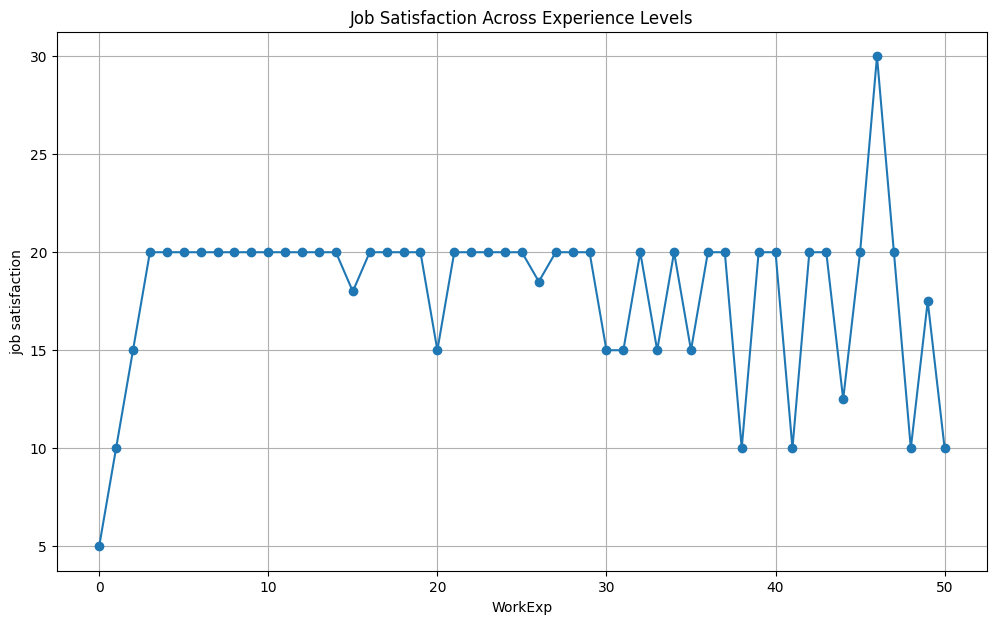

In [11]:
## Write your code here

median_satisfaction=exp_sat.groupby('WorkExp')['JobSatPoints_6'].median()

median_satisfaction.plot(
    kind='line'
    ,marker='o'
    ,grid=True
    ,figsize=(12,7)
    ,ylabel='job satisfaction'
    ,title='Job Satisfaction Across Experience Levels'
)
plt.show()

#### Final Step: Review


In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.


### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
